# k-Means clustering

### Finding groups when nobody tells you the answer

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How Lloyd's algorithm works, how to choose k when there is no answer key, and the failure modes k-means cannot see itself |
| **You should already know** | [PCA](../../06-dimensionality-reduction/01-principal-component-analysis/) helps for the plots, but is not required |
| **Dataset** | UCI Dry Bean (13,611 × 16) — labels hidden during clustering, then used to grade it |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [05-02 Choosing k](../02-choosing-k/) · [05-04 DBSCAN](../04-dbscan-and-hdbscan/) |

---

## 1. The idea

Everything so far has been **supervised**: you had labels and learned to predict
them. Clustering has no labels. You have a pile of beans and a suspicion that
they fall into groups, and you want the algorithm to find the groups.

k-means makes one strong assumption: a cluster is **a blob around a centre**.
Given that, it looks for `k` centres such that every point is close to its
nearest one.

The algorithm, due to Lloyd, alternates two steps until nothing moves:

1. **Assign** every point to its nearest centre.
2. **Move** every centre to the mean of the points assigned to it.

That is it. Each step can only reduce the total squared distance, so it always
converges — though not necessarily to the best answer, which is section 5.

This notebook uses Dry Bean with the variety labels **hidden**. At the end we
reveal them and ask how much of the real structure k-means recovered without
ever being told it existed.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y_true = datasets.dry_bean()          # y_true is put aside until section 5
print(f"{X.shape[0]:,} beans, {X.shape[1]} measurements")
print(f"(there are really {y_true.nunique()} varieties, but the algorithm is not told)")

13,611 beans, 16 measurements
(there are really 7 varieties, but the algorithm is not told)


## 2. The maths

k-means minimises the **within-cluster sum of squares**, also called inertia:

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Every point contributes its squared distance to its own centre. Both steps of
the algorithm reduce $J$: reassigning points can only move them closer, and the
mean is by definition the point minimising squared distance to a set.

Two consequences follow directly, and both matter.

**Squared distance means scaling matters**, exactly as it did for
[k-NN](../../03-classification/02-k-nearest-neighbours/). An unscaled `Area`
column would define the clusters by itself.

**Minimising squared distance to a centre makes clusters round.** k-means cannot
find a long thin cluster or a crescent, because that shape has no centre that
every member is near. It is not a bug; it is what the objective says.

## 3. From scratch

In [2]:
class KMeansScratch:
    """Lloyd's algorithm, written out in full."""

    def __init__(self, k=7, n_iter=100, random_state=0):
        self.k = k
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.random_state)

        # Start from k randomly chosen data points rather than random coordinates,
        # so no centre begins somewhere the data never goes.
        self.centres_ = X[rng.choice(len(X), self.k, replace=False)].copy()
        self.inertia_history_ = []

        for _ in range(self.n_iter):
            # Step 1: assign. Distance from every point to every centre.
            distances = ((X[:, None, :] - self.centres_[None, :, :]) ** 2).sum(axis=2)
            labels = distances.argmin(axis=1)

            # Step 2: move. A centre with no members would produce nan, so it is
            # left where it is instead.
            new_centres = np.array([
                X[labels == i].mean(axis=0) if np.any(labels == i) else self.centres_[i]
                for i in range(self.k)
            ])

            self.inertia_history_.append(distances.min(axis=1).sum())
            if np.allclose(new_centres, self.centres_):
                break                                  # nothing moved; converged
            self.centres_ = new_centres

        self.labels_ = labels
        self.inertia_ = distances.min(axis=1).sum()
        return self


from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
mine = KMeansScratch(k=7, random_state=SEED).fit(X_scaled)

from sklearn.cluster import KMeans

theirs = KMeans(n_clusters=7, n_init=10, random_state=SEED).fit(X_scaled)

print(f"converged after {len(mine.inertia_history_)} iterations")
print(f"our inertia     : {mine.inertia_:,.0f}")
print(f"sklearn inertia : {theirs.inertia_:,.0f}")
print("(sklearn restarts 10 times and keeps the best, so it should be lower)")

converged after 69 iterations
our inertia     : 53,273
sklearn inertia : 48,812
(sklearn restarts 10 times and keeps the best, so it should be lower)


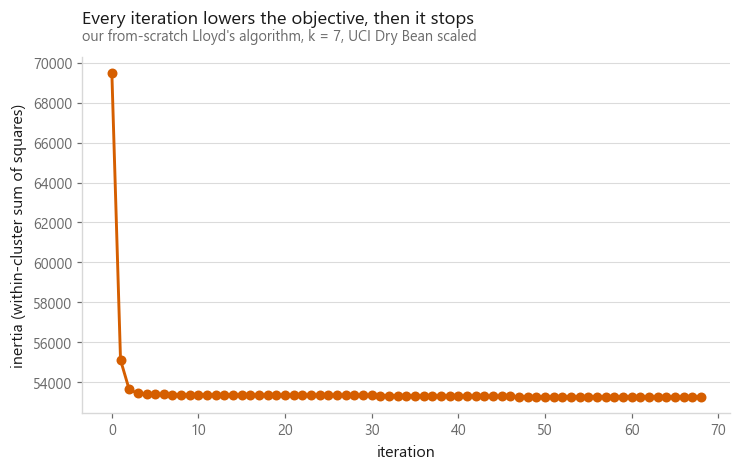

In [3]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(mine.inertia_history_, marker=style.MARKERS[0], color=style.HIGHLIGHT)
ax.set_xlabel("iteration")
ax.set_ylabel("inertia (within-cluster sum of squares)")
style.title(ax, "Every iteration lowers the objective, then it stops",
            "our from-scratch Lloyd's algorithm, k = 7, UCI Dry Bean scaled")
style.save(fig, FIG / "fig-01-convergence.png")

## 4. In practice: choosing k without an answer key

In real clustering you do not know the number of groups. Two standard tools,
neither of which is conclusive.

**The elbow.** Plot inertia against `k`. Inertia always falls as `k` rises — at
`k` equal to the number of points it reaches zero — so you look for the bend
where extra clusters stop paying.

**Silhouette.** For each point, compare how close it sits to its own cluster
against the nearest rival cluster. Scores run from -1 to 1; higher is better,
and unlike inertia it does not automatically improve with `k`.

silhouette prefers k = 3 (score 0.406)
silhouette at the true k = 7 : 0.307


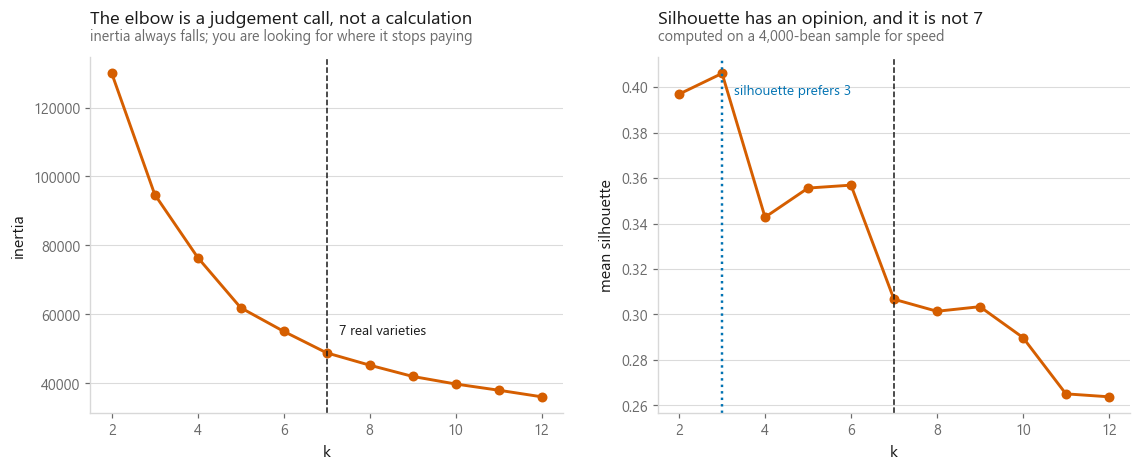

In [4]:
from sklearn.metrics import silhouette_score

k_values = list(range(2, 13))
inertias, silhouettes = [], []
sample = np.random.default_rng(SEED).choice(len(X_scaled), 4000, replace=False)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled[sample], model.labels_[sample]))

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].plot(k_values, inertias, marker=style.MARKERS[0], color=style.HIGHLIGHT)
axes[0].axvline(7, color=style.INK, ls="--", lw=1)
axes[0].annotate("7 real varieties", xy=(7, inertias[5]), xytext=(8, 12),
                 textcoords="offset points", fontsize=9, color=style.INK)
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
style.title(axes[0], "The elbow is a judgement call, not a calculation",
            "inertia always falls; you are looking for where it stops paying")

best_k = k_values[int(np.argmax(silhouettes))]
axes[1].plot(k_values, silhouettes, marker=style.MARKERS[0], color=style.HIGHLIGHT)
axes[1].axvline(7, color=style.INK, ls="--", lw=1)
axes[1].axvline(best_k, color=style.PALETTE[0], ls=":", lw=1.6)
axes[1].annotate(f"silhouette prefers {best_k}", xy=(best_k, max(silhouettes)),
                 xytext=(8, -14), textcoords="offset points", fontsize=9, color=style.PALETTE[0])
axes[1].set_xlabel("k")
axes[1].set_ylabel("mean silhouette")
style.title(axes[1], "Silhouette has an opinion, and it is not 7",
            "computed on a 4,000-bean sample for speed")

style.save(fig, FIG / "fig-02-choosing-k.png")

print(f"silhouette prefers k = {best_k} (score {max(silhouettes):.3f})")
print(f"silhouette at the true k = 7 : {silhouettes[5]:.3f}")

This is the honest state of clustering: the tools disagree with the truth and
with each other. There are seven varieties of bean in this dataset, and neither
diagnostic points confidently at seven. If you had no labels — the situation
clustering is *for* — you would probably have chosen wrong.

## 5. When it wins, when it loses

Now the labels come out. How much of the real variety structure did k-means
recover without ever seeing it?

adjusted Rand index      : 0.669
normalised mutual info   : 0.714
(1.0 would be perfect agreement, 0.0 would be chance)


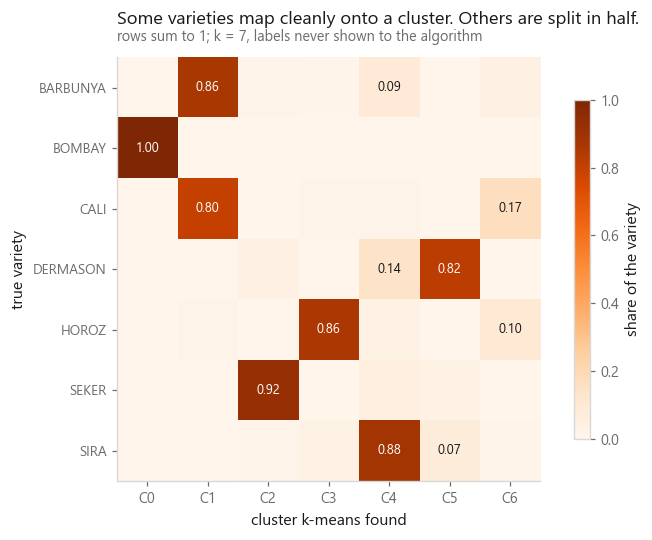

In [5]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

final = KMeans(n_clusters=7, n_init=10, random_state=SEED).fit(X_scaled)
crosstab = pd.crosstab(y_true, final.labels_, normalize="index")

fig, ax = plt.subplots(figsize=(7.8, 5.0))
image = ax.imshow(crosstab.values, cmap="Oranges", vmin=0, vmax=1)
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        value = crosstab.values[i, j]
        if value >= 0.05:
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8.5,
                    color="white" if value > 0.55 else style.INK)
ax.set_xticks(range(crosstab.shape[1]), [f"C{c}" for c in crosstab.columns])
ax.set_yticks(range(crosstab.shape[0]), crosstab.index, fontsize=9)
ax.set_xlabel("cluster k-means found")
ax.set_ylabel("true variety")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="share of the variety")
style.title(ax, "Some varieties map cleanly onto a cluster. Others are split in half.",
            "rows sum to 1; k = 7, labels never shown to the algorithm")
style.save(fig, FIG / "fig-03-clusters-vs-truth.png")

print(f"adjusted Rand index      : {adjusted_rand_score(y_true, final.labels_):.3f}")
print(f"normalised mutual info   : {normalized_mutual_info_score(y_true, final.labels_):.3f}")
print("(1.0 would be perfect agreement, 0.0 would be chance)")

### The failure k-means cannot see

The deeper problem is that k-means will return `k` tidy clusters whether or not
`k` tidy clusters exist. It has no way of telling you that the answer is
meaningless, because inertia goes down either way.

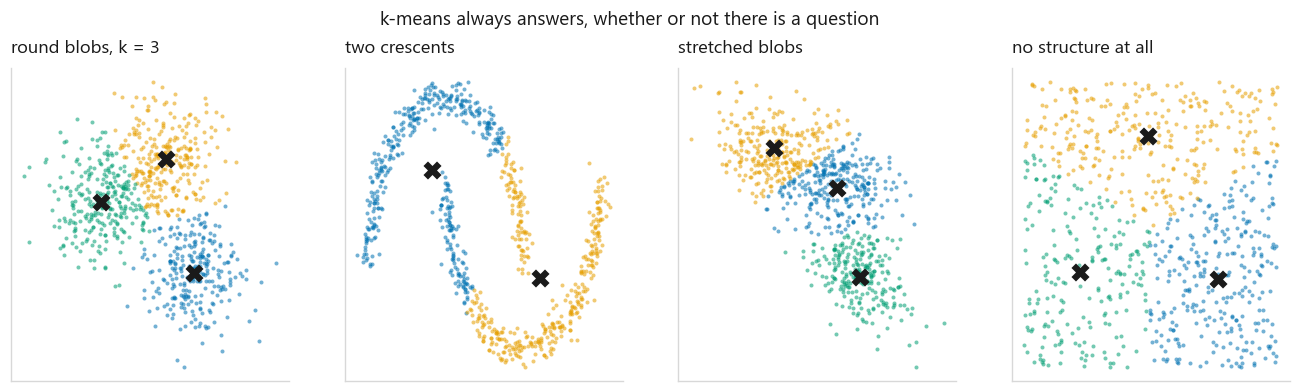

In [6]:
from sklearn.datasets import make_blobs, make_moons

rng = np.random.default_rng(SEED)
shapes = {
    "round blobs, k = 3": make_blobs(n_samples=800, centers=3, cluster_std=1.0, random_state=SEED)[0],
    "two crescents": make_moons(n_samples=800, noise=0.06, random_state=SEED)[0],
    "stretched blobs": make_blobs(n_samples=800, centers=3, random_state=SEED)[0] @ [[0.7, -0.7], [0.1, 0.9]],
    "no structure at all": rng.uniform(-3, 3, size=(800, 2)),
}
wanted = {"round blobs, k = 3": 3, "two crescents": 2, "stretched blobs": 3, "no structure at all": 3}

fig, axes = plt.subplots(1, 4, figsize=(15.0, 3.7))
for ax, (name, points) in zip(axes, shapes.items()):
    model = KMeans(n_clusters=wanted[name], n_init=10, random_state=SEED).fit(points)
    for c in range(wanted[name]):
        sel = model.labels_ == c
        ax.scatter(points[sel, 0], points[sel, 1], s=7, alpha=0.55,
                   c=style.PALETTE[c], linewidths=0)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
               s=140, marker="X", c=style.INK, linewidths=0, zorder=5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    style.title(ax, name)

fig.suptitle("k-means always answers, whether or not there is a question",
             x=0.5, y=1.02, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-failure-modes.png")

Read the four panels left to right.

**Round blobs** is the case k-means was designed for, and it nails it.

**Two crescents** is the classic failure. The clusters are obvious to your eye
and impossible for k-means, because neither crescent has a centre its members
are near. [DBSCAN](../04-dbscan-and-hdbscan/) handles this by defining clusters
through density instead.

**Stretched blobs** fails more subtly. The groups are real but elongated, and
because k-means measures plain Euclidean distance it slices them across the
grain. [Gaussian mixtures](../05-gaussian-mixture-models/) fix this by giving
each cluster its own shape.

**No structure at all** is uniform random noise, and k-means confidently returns
three neat wedges. This is the one to remember: **the output of a clustering
algorithm is not evidence that clusters exist.** Nothing in the method will ever
tell you the answer is meaningless. That check is your job.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Clusters are roughly round and similarly sized, you have a rough idea of k, and the data is large (it scales well) |
| **Avoid it when** | Clusters are elongated, nested, crescent-shaped, or wildly different in size; outliers are common (they drag centres) |
| **Scaling needed** | Yes, always. Squared distance means the largest-unit column dominates |
| **Main dials** | `n_clusters`, `n_init` (keep it at 10 or more), `init` (k-means++ is the sensible default) |
| **Watch out** | It converges to a local minimum, so different seeds give different answers. It also clusters pure noise without complaint |
| **Next** | [Choosing k](../02-choosing-k/) properly, then [DBSCAN](../04-dbscan-and-hdbscan/) for shapes k-means cannot see |

## What to remember

1. Assign, move, repeat. Both steps lower inertia, so it always converges.
2. Convergence is to a *local* minimum. Restart several times, which `n_init` does.
3. Scale first, or the biggest unit becomes the clustering.
4. The objective makes clusters round. Long, thin, or nested shapes are out of reach.
5. Elbow and silhouette are hints, not answers, and on real data they disagree.
6. k-means will cluster pure noise into tidy groups. Structure in the output is
   not evidence of structure in the data.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-02 Choosing k](../02-choosing-k/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#KMeans` `#Clustering` `#UnsupervisedLearning` `#Python`
`#ScikitLearn` `#DataScience` `#MLTutorial` `#Silhouette` `#LearnMachineLearning`